<a href="https://colab.research.google.com/github/Decoding-Data-Science/enecoct2026/blob/main/Day_1_Copilot_and_Data_Understanding/00_reading_sql_table.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os
import sqlite3
import pandas as pd

# Define the data directory
data_dir = 'data_nuclear'

# Find all database files in the data directory
db_files = [f for f in os.listdir(data_dir) if f.endswith(('.db', '.sqlite', '.sqlite3'))] if os.path.exists(data_dir) else []

if not db_files:
    print(f"No SQLite database files found in '{data_dir}' folder. Please make sure your database file is placed there.")
else:
    # Connect to the first database found
    db_path = os.path.join(data_dir, db_files[0])
    print(f"Connecting to database: {db_path}")
    conn = sqlite3.connect(db_path)

    # List all tables in the database
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print("Tables in database:", [t[0] for t in tables])

    if tables:
        # Read the first table into a pandas DataFrame
        table_name = tables[0][0]
        print(f"Reading table '{table_name}'...")
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        conn.close()

        # Display the first few rows of the DataFrame
        display(df.head())
    else:
        print("No tables found in the database.")
        conn.close()

Connecting to database: data_nuclear/ENEC2026_NE360_Full_Cyber.db
Tables in database: ['dataset_metadata', 'departments', 'units', 'systems', 'assets', 'sensor_readings', 'asset_health_scores', 'work_orders', 'inspections', 'maintenance_history', 'projects', 'project_kpis', 'risks', 'actions', 'employees', 'training_records', 'documents', 'document_chunks', 'agent_runs', 'agent_tool_calls', 'human_approvals', 'project_assets', 'risk_assets', 'document_entity_links', 'sensor_readings_a001_1min', 'a001_source_documents', 'a001_source_document_links', 'asset_security', 'asset_priority_view', 'security_vulnerabilities', 'security_incidents', 'security_access_review', 'security_alerts', 'security_auth_logs', 'security_network_flows', 'security_controller_commands', 'security_accounts', 'security_network_zones', 'security_documents', 'security_log_windows', 'security_persona_questions', 'security_role_task_cards', 'security_eval_questions', 'ot_controllers', 'ot_safety_interlocks', 'vendors'

,metadata_key,metadata_value
0,dataset_name,Nuclear Enterprise 360 AI Training Dataset
1,dataset_version,1.0.0
2,generated_on,2026-08-25
3,random_seed,3602026
4,data_classification,SYNTHETIC TRAINING DATA


In [9]:
import sqlite3
import pandas as pd

# 1. Connect to the database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# 2. Get list of all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]

# 3. Fetch row counts for each table
table_counts = []
for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM `{table}`")
    row_count = cursor.fetchone()[0]
    table_counts.append({"Table Name": table, "Row Count": row_count})

# 4. Close the connection
conn.close()

# 5. Display as a clean pandas DataFrame
df_counts = pd.DataFrame(table_counts)
display(df_counts)

,Table Name,Row Count
0,dataset_metadata,53
1,departments,8
2,units,4
3,systems,16
4,assets,128
5,sensor_readings,47540
6,asset_health_scores,11520
7,work_orders,1500
8,inspections,600
9,maintenance_history,900


In [10]:
import sqlite3
import pandas as pd

# 1. Connect to the SQLite database
# We use the db_path variable defined in the previous cell
conn = sqlite3.connect(db_path)

# Let's load the 'assets' table which has actual system/asset data for analysis
target_table = 'assets'
print(f"--- Starting EDA for Table: {target_table} ---\n")

# Load the table data into a pandas DataFrame
df_assets = pd.read_sql_query(f"SELECT * FROM {target_table}", conn)

# Close the database connection as we have loaded the data we need
conn.close()

# 2. Look at the size of the dataset (Rows and Columns)
print("1. Shape of the Dataset (Rows, Columns):")
print(df_assets.shape)
print("\n" + "="*50 + "\n")

# 3. View the first 5 rows of our data
print("2. First 5 Rows of Data:")
display(df_assets.head())
print("\n" + "="*50 + "\n")

# 4. Check data types and find any missing (null) values
print("3. Column Information and Missing Values:")
# info_df will show data types and non-null counts for each column
df_info = pd.DataFrame({
    'Data Type': df_assets.dtypes,
    'Missing Values (NaN)': df_assets.isnull().sum(),
    'Total Values': len(df_assets)
})
display(df_info)
print("\n" + "="*50 + "\n")

# 5. Get statistical summaries for numeric columns (mean, min, max, etc.)
print("4. Statistical Summary (Numeric Columns):")
display(df_assets.describe())
print("\n" + "="*50 + "\n")

# 6. Check unique value counts for categorical columns (like status, type, etc.)
print("5. Unique Value Counts in Categorical Columns:")
# Find text columns
text_cols = df_assets.select_dtypes(include=['object']).columns
for col in text_cols:
    # Only display if there are relatively few unique categories
    num_unique = df_assets[col].nunique()
    if num_unique < 15:
        print(f"\nUnique values in '{col}':")
        print(df_assets[col].value_counts())


--- Starting EDA for Table: assets ---

1. Shape of the Dataset (Rows, Columns):
(128, 9)


2. First 5 Rows of Data:


,asset_id,system_id,asset_name,asset_type,criticality,manufacturer,installation_date,status,maintenance_interval_days
0,A-001,TRN-A-SYS-01,Pump 001,Pump,HIGH,Fictional Dynamics,2019-05-30,IN_SERVICE,365
1,A-002,TRN-A-SYS-01,Motor 002,Motor,HIGH,Fictional Dynamics,2021-05-23,IN_SERVICE,90
2,A-003,TRN-A-SYS-01,Valve 003,Valve,MEDIUM,SimuTech,2021-02-01,IN_SERVICE,180
3,A-004,TRN-A-SYS-01,Heat Exchanger 004,Heat Exchanger,LOW,TrainingWorks,2019-03-19,IN_SERVICE,365
4,A-005,TRN-A-SYS-01,Fan 005,Fan,LOW,Demo Industrial,2021-10-02,IN_SERVICE,90




3. Column Information and Missing Values:


,Data Type,Missing Values (NaN),Total Values
asset_id,object,0,128
system_id,object,0,128
asset_name,object,0,128
asset_type,object,0,128
criticality,object,0,128
manufacturer,object,0,128
installation_date,object,0,128
status,object,0,128
maintenance_interval_days,int64,0,128




4. Statistical Summary (Numeric Columns):


,maintenance_interval_days
count,128.000000
mean,198.984375
std,109.136481
min,90.000000
25%,120.000000
50%,180.000000
75%,365.000000
max,365.000000




5. Unique Value Counts in Categorical Columns:

Unique values in 'asset_type':
asset_type
Pump              16
Motor             16
Valve             16
Heat Exchanger    16
Fan               16
Compressor        16
Transformer       16
Filter            16
Name: count, dtype: int64

Unique values in 'criticality':
criticality
MEDIUM    63
HIGH      37
LOW       28
Name: count, dtype: int64

Unique values in 'manufacturer':
manufacturer
Fictional Dynamics    33
SimuTech              33
TrainingWorks         32
Demo Industrial       30
Name: count, dtype: int64

Unique values in 'status':
status
IN_SERVICE     112
MONITOR         12
MAINTENANCE      4
Name: count, dtype: int64


In [6]:
import sqlite3
import pandas as pd

# 1. Connect to the database using the defined path
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# 2. Get the list of all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]

# 3. Loop through each table and display its first 5 rows
for table_name in tables:
    print(f"\n" + "="*60)
    print(f" TABLE: {table_name} ")
    print("="*60)

    # Read the table data
    df_temp = pd.read_sql_query(f"SELECT * FROM `{table_name}` LIMIT 5;", conn)

    # Display the top 5 rows
    if not df_temp.empty:
        display(df_temp)
    else:
        print("[Empty Table]")

# Close the connection
conn.close()


 TABLE: dataset_metadata 


,metadata_key,metadata_value
0,dataset_name,Nuclear Enterprise 360 AI Training Dataset
1,dataset_version,1.0.0
2,generated_on,2026-08-25
3,random_seed,3602026
4,data_classification,SYNTHETIC TRAINING DATA



 TABLE: departments 


,department_id,department_name,manager_code,location,cost_center
0,D-ENG,Engineering,MGR-ENG,Abu Dhabi,CC100
1,D-PMO,Project Management,MGR-PMO,Abu Dhabi,CC110
2,D-MNT,Maintenance,MGR-MNT,Training Site,CC120
3,D-QLT,Quality and Performance,MGR-QLT,Abu Dhabi,CC130
4,D-HSE,Health Safety and Environment,MGR-HSE,Training Site,CC140



 TABLE: units 


...

,reading_timestamp,asset_id,temperature_c,vibration_mm_s,pressure_bar,flow_rate_m3_h,electrical_current_a,ambient_temperature_c,sensor_quality,anomaly_flag,operating_state,data_origin
0,2025-08-25T18:00:00,A-001,51.700,0.9710,8.470,96.450,36.430,29.270,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC
1,2025-08-25T18:01:00,A-001,51.702,0.9712,8.471,96.444,36.433,29.272,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC
2,2025-08-25T18:02:00,A-001,51.704,0.9715,8.472,96.438,36.435,29.274,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC
3,2025-08-25T18:03:00,A-001,51.706,0.9717,8.472,96.430,36.437,29.276,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC
4,2025-08-25T18:04:00,A-001,51.708,0.9719,8.473,96.423,36.439,29.278,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC



 TABLE: a001_source_documents 


,document_id,title,document_type,approval_status,version,effective_date,owner,asset_id,source_file_name,package_path
0,REL-POL-001,Enterprise Asset Reliability and Escalation Po...,POLICY,APPROVED,2.1,2026-07-01,Reliability Governance Office,A-001,01_REL-POL-001_Enterprise_Asset_Reliability_an...,documents/a001/01_REL-POL-001_Enterprise_Asset...
1,A001-OPS-001,A-001 Operating and Usage Guide,OPERATING_GUIDE,APPROVED,1.4,2026-05-15,Utilities Engineering,A-001,02_A001-OPS-001_Operating_and_Usage_Guide(1).pdf,documents/a001/02_A001-OPS-001_Operating_and_U...
2,A001-PROC-INS-001-V1,A-001 Condition Inspection Procedure - Histori...,PROCEDURE,SUPERSEDED,1.0,2025-03-01,Maintenance Engineering,A-001,03_A001-PROC-INS-001-V1_Superseded_Inspection_...,documents/a001/03_A001-PROC-INS-001-V1_Superse...
3,A001-PROC-INS-001-V2,A-001 Condition Inspection and Preventive Main...,PROCEDURE,APPROVED,2.0,2026-02-01,Maintenance Engineering,A-001,04_A001-PROC-INS-001-V2_Approved_Inspection_an...,documents/a001/04_A001-PROC-INS-001-V2_Approve...
4,A001-PROC-INS-001-V3D,A-001 Condition Inspection Procedure - Draft R...,PROCEDURE,DRAFT,3.0-draft,2026-08-20,Maintenance Engineering,A-001,05_A001-PROC-INS-001-V3D_Draft_Procedure(1).pdf,documents/a001/05_A001-PROC-INS-001-V3D_Draft_...



 TABLE: a001_source_document_links 


,link_id,document_id,entity_type,entity_id,relationship_type,evidence_date,notes
0,A001-EV-001,REL-POL-001,ASSET,A-001,APPLIES_TO,2026-07-01,Source document explicitly identifies A-001.
1,A001-EV-002,A001-OPS-001,ASSET,A-001,APPLIES_TO,2026-05-15,Source document explicitly identifies A-001.
2,A001-EV-003,A001-PROC-INS-001-V1,ASSET,A-001,APPLIES_TO,2025-03-01,Source document explicitly identifies A-001.
3,A001-EV-004,A001-PROC-INS-001-V2,ASSET,A-001,APPLIES_TO,2026-02-01,Source document explicitly identifies A-001.
4,A001-EV-005,A001-PROC-INS-001-V3D,ASSET,A-001,APPLIES_TO,2026-08-20,Source document explicitly identifies A-001.


/tmp/ipykernel_1079/493764557.py:64: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


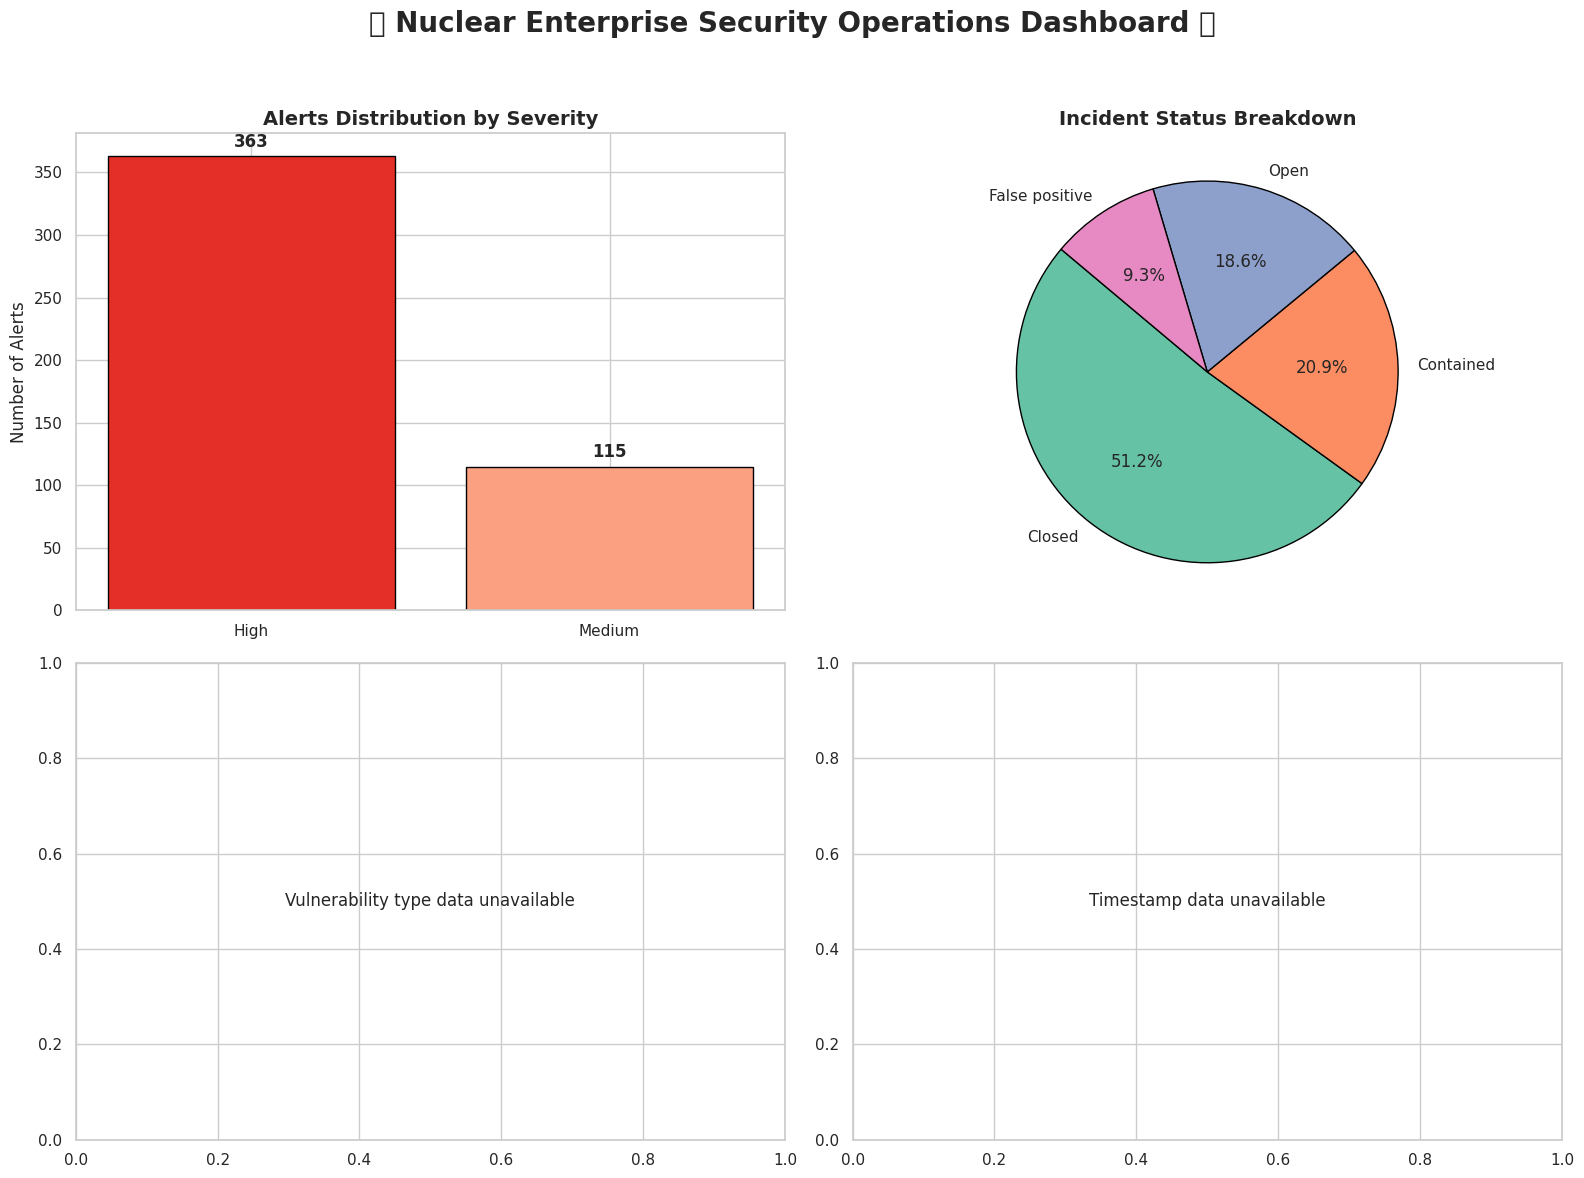

📝 SECURITY OVERVIEW SUMMARY
Total Active Alerts:         478
Total Identified Vulnerabilities: 174
Total Security Incidents:    43


In [11]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to the database
conn = sqlite3.connect(db_path)

# 2. Load the security tables
df_alerts = pd.read_sql_query("SELECT * FROM security_alerts", conn)
df_vuln = pd.read_sql_query("SELECT * FROM security_vulnerabilities", conn)
df_incidents = pd.read_sql_query("SELECT * FROM security_incidents", conn)
conn.close()

# Set seaborn style for clean visualizations
sns.set_theme(style="whitegrid")

# Create a multi-plot layout dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("🚨 Nuclear Enterprise Security Operations Dashboard 🚨", fontsize=20, fontweight='bold', y=0.98)

# --- PLOT 1: Security Alerts by Severity ---
if 'severity' in df_alerts.columns:
    severity_counts = df_alerts['severity'].value_counts()
    colors = sns.color_palette("Reds_r", len(severity_counts))
    axes[0, 0].bar(severity_counts.index, severity_counts.values, color=colors, edgecolor='black')
    axes[0, 0].set_title("Alerts Distribution by Severity", fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel("Number of Alerts")
    for idx, val in enumerate(severity_counts.values):
        axes[0, 0].text(idx, val + (max(severity_counts.values)*0.02), str(val), ha='center', fontweight='bold')
else:
    axes[0, 0].text(0.5, 0.5, 'Severity data unavailable', ha='center', va='center')

# --- PLOT 2: Open vs Closed Incidents ---
if 'status' in df_incidents.columns:
    status_counts = df_incidents['status'].value_counts()
    axes[0, 1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=140,
                  colors=sns.color_palette("Set2", len(status_counts)), wedgeprops={'edgecolor': 'black'})
    axes[0, 1].set_title("Incident Status Breakdown", fontsize=14, fontweight='bold')
else:
    axes[0, 1].text(0.5, 0.5, 'Incident status data unavailable', ha='center', va='center')

# --- PLOT 3: Vulnerabilities by Category/Type ---
if 'vulnerability_type' in df_vuln.columns:
    vuln_types = df_vuln['vulnerability_type'].value_counts().head(8)
    sns.barplot(x=vuln_types.values, y=vuln_types.index, ax=axes[1, 0], palette="viridis", hue=vuln_types.index, legend=False)
    axes[1, 0].set_title("Top Vulnerability Types Detected", fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel("Count")
else:
    axes[1, 0].text(0.5, 0.5, 'Vulnerability type data unavailable', ha='center', va='center')

# --- PLOT 4: Alerts Over Time ---
if 'timestamp' in df_alerts.columns:
    df_alerts['timestamp_parsed'] = pd.to_datetime(df_alerts['timestamp'])
    alerts_over_time = df_alerts.groupby(df_alerts['timestamp_parsed'].dt.date).size()
    axes[1, 1].plot(alerts_over_time.index, alerts_over_time.values, marker='o', color='#d9534f', linewidth=2)
    axes[1, 1].set_title("Security Alerts Trend Over Time", fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel("Number of Alerts")
    axes[1, 1].set_xlabel("Date")
    plt.setp(axes[1, 1].get_xticklabels(), rotation=30, ha="right")
else:
    axes[1, 1].text(0.5, 0.5, 'Timestamp data unavailable', ha='center', va='center')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Summary stats printable view
print("="*60)
print("📝 SECURITY OVERVIEW SUMMARY")
print("="*60)
print(f"Total Active Alerts:         {len(df_alerts)}")
print(f"Total Identified Vulnerabilities: {len(df_vuln)}")
print(f"Total Security Incidents:    {len(df_incidents)}")
print("="*60)
